# 引入必要库

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# 加载数据

In [3]:
daily_input_file = "basic_data/daily_data.parquet"
industry_input_file = "basic_data/industry.parquet"
st_input_file = "basic_data/st.parquet"
suspended_input_file = "basic_data/停牌.parquet"

daily_data = pd.read_parquet(daily_input_file)
industry_data = pd.read_parquet(industry_input_file)
st_data = pd.read_parquet(st_input_file)
suspended_data = pd.read_parquet(suspended_input_file)

print("daily_data shape:", daily_data.shape)
print("industry_data shape:", industry_data.shape)
print("st_data shape:", st_data.shape)
print("suspended_data shape:", suspended_data.shape)


daily_data shape: (8717164, 13)
industry_data shape: (9012858, 4)
st_data shape: (3159, 5370)
suspended_data shape: (8730456, 3)


In [4]:
# 数据概览
print("=== daily_data ===")
print("Index:", daily_data.index.names)
print("Columns:", daily_data.columns.tolist())
print("Date range:", daily_data.index.get_level_values(0).min(), "to", daily_data.index.get_level_values(0).max())
print("Unique stocks:", daily_data.index.get_level_values(1).nunique())
print()

print("=== industry_data ===")
print("Index:", industry_data.index.names)
print("Columns:", industry_data.columns.tolist())
print(industry_data.head(2))
print()

print("=== st_data ===")
print("Index type:", st_data.index.name)
print("Shape:", st_data.shape)
print("Sample:", st_data.iloc[:3, :3])
print()

print("=== suspended_data ===")
print("Columns:", suspended_data.columns.tolist())
print("Sample:", suspended_data.head())


=== daily_data ===
Index: ['DATE', 'CODE']
Columns: ['AVERAGE_PRICE', 'DY-ADJ_AF-CLOSE_PRICE_2', 'DY-ADJ_AF-HIGHEST_PRICE_2', 'DY-ADJ_AF-LOWEST_PRICE_2', 'DY-ADJ_AF-OPEN_PRICE_2', 'DY-ADJ_AF-TURNOVER_VOL', 'DY-BASIC-DEAL_AMOUNT', 'DY-BASIC-MARKET_VALUE', 'DY-BASIC-NEG_MARKET_VALUE', 'DY-BASIC-TURNOVER_RATE', 'DY-BASIC-TURNOVER_VALUE', 'DY-IND-CHG_STATUS', 'DY-IND-DEAL_VALUE']
Date range: 2010-01-04 to 2021-12-31
Unique stocks: 4687

=== industry_data ===
Index: ['CODE', 'DATE']
Columns: ['TYPE_ID', 'LEVEL1_NAME', 'LEVEL2_NAME', 'LEVEL3_NAME']
                        TYPE_ID LEVEL1_NAME LEVEL2_NAME LEVEL3_NAME
CODE   DATE                                                        
000001 20100104  DY010321330101        金融服务          银行          银行
       20100105  DY010321330101        金融服务          银行          银行

=== st_data ===
Index type: None
Shape: (3159, 5370)
Sample:          000001 000002 000003
20100104   None   None      T
20100105   None   None      T
20100106   None   None     


# 数据清洗与剔除

In [23]:

# 0. 先把 daily_data 日期索引统一为 datetime，并重命名索引
daily_data = daily_data.copy()
daily_data.index = pd.MultiIndex.from_arrays([
    pd.to_datetime(daily_data.index.get_level_values(0)),
    daily_data.index.get_level_values(1)
], names=['date', 'code'])

# 列重命名
daily_data = daily_data.rename(columns={
    'DY-ADJ_AF-OPEN_PRICE_2': 'open',
    'DY-ADJ_AF-HIGHEST_PRICE_2': 'high',
    'DY-ADJ_AF-LOWEST_PRICE_2': 'low',
    'DY-ADJ_AF-CLOSE_PRICE_2': 'close',
    'DY-BASIC-MARKET_VALUE': '市值'
})

# 1. 停牌数据对齐：
sp = suspended_data.copy()
sp.columns = ['code', 'date', 'is_suspended']
sp = sp.set_index(['date', 'code'])['is_suspended']

# 2. ST 数据对齐：
st = st_data.copy()
st.index = pd.to_datetime(st.index, format='%Y%m%d')
st_long = st.stack().reset_index()
st_long.columns = ['date', 'code', 'st_flag']
st_long['is_st'] = st_long['st_flag'].notna() 
st_long = st_long.set_index(['date', 'code'])['is_st']

# 3. 合并到主表
df = daily_data.copy()
df = df.join(sp, how='left')
df = df.join(st_long, how='left')

# 缺失值填充
df['is_suspended'] = df['is_suspended'].fillna(0).astype(bool)
df['is_st'] = df['is_st'].fillna(False)

# 4. 涨跌停判断：
# 用9.5%作为阈值
# 涨停：收益率>=+9.5% 且 收盘价等于最高价；跌停：收益率<=-9.5% 且 收盘价等于最低价
df = df.sort_index()
df['pre_close'] = df.groupby('code')['close'].shift(1)
df['ret'] = df['close'] / df['pre_close'] - 1

df['is_up_limit'] = (df['ret'] >= 0.095) & (df['close'] == df['high'])
df['is_down_limit'] = (df['ret'] <= -0.095) & (df['close'] == df['low'])
df['is_limit'] = df['is_up_limit'] | df['is_down_limit']

# 5. 上市天数计算（自然日）
first_trade = df.groupby(level=1).apply(lambda x: x.index.get_level_values(0).min())
df['first_trade_date'] = df.index.get_level_values(1).map(first_trade)
df['days_since_listing'] = (df.index.get_level_values(0) - df['first_trade_date']).dt.days

# 数据起始日就存在的股票，默认不是新股
data_start = df.index.get_level_values(0).min()
df.loc[df['first_trade_date'] == data_start, 'days_since_listing'] = 9999

# 6. 有效样本标记
df['valid'] = (
    (~df['is_limit']) &
    (~df['is_suspended']) &
    (~df['is_st']) &
    (df['days_since_listing'] >= 60)
)

# 7. 统计信息
print("=" * 40)
print("数据清洗统计")
print("=" * 40)
print(f"总记录数: {len(df):,}")
print(f"当日有效样本数: {df['valid'].sum():,}")
print(f"有效比例: {df['valid'].mean():.2%}")
print()

print("各剔除条件占比:")
print(f"  涨停:   {df['is_up_limit'].mean():.2%}")
print(f"  跌停:   {df['is_down_limit'].mean():.2%}")
print(f"  停牌:   {df['is_suspended'].mean():.2%}")
print(f"  ST:     {df['is_st'].mean():.2%}")
print(f"  新股(<60天): {(df['days_since_listing'] < 60).mean():.2%}")

C:\Users\HP\AppData\Local\Temp\ipykernel_13196\3638839150.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_st'] = df['is_st'].fillna(False)


数据清洗统计
总记录数: 8,717,164
当日有效样本数: 7,736,052
有效比例: 88.75%

各剔除条件占比:
  涨停:   1.54%
  跌停:   0.79%
  停牌:   4.70%
  ST:     3.85%
  新股(<60天): 1.35%



# 计算因子与收益率


In [6]:
df_reset = df.reset_index()

# 因子：5日价格动量 close_t0 / close_t-5 - 1
df_reset['factor'] = df_reset.groupby('code')['close'].transform(
    lambda x: x / x.shift(5) - 1
)

# 1. 先标记 t1 日有效性
df_reset['valid_t1'] = df_reset.groupby('code')['valid'].shift(-1)

# 2. 提取 open_t1 和 open_t2，同时把无效样本的价格清为 NaN
df_reset['open_t1'] = df_reset.groupby('code')['open'].shift(-1)
df_reset['open_t2'] = df_reset.groupby('code')['open'].shift(-2)
df_reset.loc[df_reset['valid_t1'] == False, ['open_t1', 'open_t2']] = np.nan

# 3. 计算收益率
df_reset['return'] = df_reset['open_t2'] / df_reset['open_t1'] - 1

df_reset['return'] = df_reset['return'].replace([np.inf, -np.inf], np.nan)

# 4. 排除 open_t1 或 open_t2 为 0/负值 的异常样本（避免 -100% 极端离群值）
df_reset.loc[(df_reset['open_t1'] <= 0) | (df_reset['open_t2'] <= 0), 'return'] = np.nan

# 恢复索引
df = df_reset.set_index(['date', 'code']).sort_index()

# 统计
print("=" * 40)
print("因子与收益率统计")
print("=" * 40)
print(f"总记录数: {len(df):,}")
print(f"t1 日有效样本数: {df['valid_t1'].sum():,}")
print(f"有效比例: {df['valid_t1'].mean():.2%}")
print()

# 因子和收益率的描述统计（仅有效样本）
valid_df = df_reset[df_reset['valid_t1'] == True]


def print_describe_pct(series, title):
    desc = series.describe()
    print(f"{title}描述统计:")
    for k, v in desc.items():
        if k == 'count':
            print(f"  {k:>6s}: {v:,.0f}")
        else:
            print(f"  {k:>6s}: {v*100:>10.2f}%")
    print()


print_describe_pct(valid_df['factor'], "有效样本中因子")
print_describe_pct(valid_df['return'], "有效样本中收益率")

因子与收益率统计
总记录数: 8,717,164
t1 日有效样本数: 7,734,536
有效比例: 88.78%

有效样本中因子描述统计:
   count: 7,727,082
    mean:       0.25%
     std:       6.89%
     min:     -64.37%
     25%:      -3.33%
     50%:       0.00%
     75%:       3.44%
     max:    1676.65%

有效样本中收益率描述统计:
   count: 7,703,846
    mean:      -0.02%
     std:       2.74%
     min:     -38.54%
     25%:      -1.43%
     50%:       0.00%
     75%:       1.39%
     max:      36.67%



由于数据第一天就存在的数据无法确定上市日期，所以暂时当做不是新股，但是这样会导致计算因子值时出现nan，因此因子统计总数小于收益率

# 因子标准化（Z-score标准化、rank标准化）

In [7]:
# 在每个交易日截面上，仅对 valid_t1=True 且 return 非 NaN 的样本标准化
df_reset = df.reset_index()
df_reset['valid_for_std'] = df_reset['valid_t1'] & df_reset['return'].notna()

# 屏蔽无效样本的因子值
df_reset['factor_masked'] = df_reset['factor'].where(df_reset['valid_for_std'])

# Z-Score 标准化：
df_reset['factor_zscore'] = df_reset.groupby('date')['factor_masked'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Rank 标准化：
def rank_standardize(x):
    ranks = x.rank()
    return (ranks - ranks.mean()) / ranks.std()

df_reset['factor_rank'] = df_reset.groupby('date')['factor_masked'].transform(rank_standardize)

# 恢复索引
df = df_reset.set_index(['date', 'code']).sort_index()

# 统计
print("=" * 40)
print("标准化后因子统计（仅有效样本）")
print("=" * 40)
valid_df = df_reset[df_reset['valid_for_std']]

for col, name in [('factor_zscore', 'Z-Score'), ('factor_rank', 'Rank')]:
    desc = valid_df[col].describe()
    print(f"\n{name}:")
    for k, v in desc.items():
        if k == 'count':
            print(f"  {k:>6s}: {v:,.0f}")
        else:
            print(f"  {k:>6s}: {v:>10.4f}")

标准化后因子统计（仅有效样本）

Z-Score:
   count: 7,696,478
    mean:    -0.0000
     std:     0.9998
     min:   -11.1758
     25%:    -0.5415
     50%:    -0.1010
     75%:     0.4140
     max:    47.6829

Rank:
   count: 7,696,478
    mean:     0.0000
     std:     0.9998
     min:    -1.7314
     25%:    -0.8658
     50%:     0.0000
     75%:     0.8658
     max:     1.7314


In [8]:
df_reset = df.reset_index()

# 1. 合并行业数据（一级行业）
if 'LEVEL1_NAME' not in df_reset.columns:
    print("正在合并行业数据...")
    ind = industry_data.reset_index()
    ind['DATE'] = pd.to_datetime(ind['DATE'], format='%Y%m%d')
    ind = ind.rename(columns={'CODE': 'code', 'DATE': 'date'})
    df_reset = df_reset.merge(
        ind[['date', 'code', 'LEVEL1_NAME']], 
        on=['date', 'code'], 
        how='left'
    )

# 2. 对数市值
df_reset['log_mv'] = np.log(df_reset['市值'])
df_reset['log_mv'] = df_reset['log_mv'].replace([-np.inf, np.inf], np.nan)

# 3. 中性化函数（statsmodels OLS）
def neutralize_factor(df_sub, factor_col):
    mask = (
        df_sub[factor_col].notna() & 
        df_sub['log_mv'].notna() & 
        df_sub['LEVEL1_NAME'].notna()
    )
    valid = df_sub[mask].copy()
    
    n = len(valid)
    n_industries = valid['LEVEL1_NAME'].nunique()
    
    if n < 20 or n < n_industries + 2:
        return pd.Series(np.nan, index=df_sub.index)
    
    try:
        # 行业虚拟变量
        dummies = pd.get_dummies(valid['LEVEL1_NAME'], prefix='ind', drop_first=True)
        
        # 自变量
        X = pd.concat([valid[['log_mv']], dummies], axis=1)
        X = sm.add_constant(X, has_constant='add')
        y = valid[factor_col]
        
        # OLS 回归
        X = X.astype(float)
        y = y.astype(float)
        model = sm.OLS(y, X, missing='drop').fit()
        
        resid = pd.Series(np.nan, index=df_sub.index)
        resid.loc[valid.index] = model.resid
        return resid
        
    except Exception as e:
        print(f"  Warning: {df_sub['date'].iloc[0]} 回归失败: {e}")
        return pd.Series(np.nan, index=df_sub.index)

# 4. 执行中性化
print("正在进行市值+行业中性化...")
for col, out_col in [('factor_zscore', 'factor_zscore_neu'), ('factor_rank', 'factor_rank_neu')]:
    resid_list = []
    for date, group in df_reset.groupby('date'):
        resid = neutralize_factor(group, col)
        resid_list.append(resid)
    df_reset[out_col] = pd.concat(resid_list)
    print(f"  {out_col} 完成, 非NaN数: {df_reset[out_col].notna().sum():,}")

# 恢复索引
df = df_reset.set_index(['date', 'code']).sort_index()

# 5. 统计
print("\n" + "=" * 40)
print("中性化后因子统计（仅有效样本）")
print("=" * 40)
valid_df = df_reset[df_reset['valid_for_std']]

for col, name in [('factor_zscore_neu', 'Z-Score中性化'), ('factor_rank_neu', 'Rank中性化')]:
    desc = valid_df[col].describe()
    print(f"\n{name}:")
    for k, v in desc.items():
        if k == 'count':
            print(f"  {k:>6s}: {v:,.0f}")
        else:
            print(f"  {k:>6s}: {v:>10.4f}")

正在合并行业数据...
正在进行市值+行业中性化...
  factor_zscore_neu 完成, 非NaN数: 7,696,478
  factor_rank_neu 完成, 非NaN数: 7,696,478

中性化后因子统计（仅有效样本）

Z-Score中性化:
   count: 7,696,478
    mean:    -0.0000
     std:     0.9482
     min:   -11.2337
     25%:    -0.5012
     50%:    -0.0840
     75%:     0.3815
     max:    47.3185

Rank中性化:
   count: 7,696,478
    mean:    -0.0000
     std:     0.9356
     min:    -3.3883
     25%:    -0.7463
     50%:    -0.0042
     75%:     0.7421
     max:     3.2915


# 计算原始和和中性化后因子IC值（因子选择rank标准化）

In [9]:
df_reset = df.reset_index()

# 计算截面 Spearman IC
def calc_ic(group, factor_col):
    valid = group[group[factor_col].notna() & group['return'].notna()]
    if len(valid) < 10:
        return np.nan
    return valid[factor_col].corr(valid['return'], method='spearman')

# 分别计算两种因子的 IC 序列：Rank原始 和 Rank中性化
ic_results = {}
for col, name in [('factor_rank', 'Rank原始'), ('factor_rank_neu', 'Rank中性化')]:
    ic_series = df_reset.groupby('date').apply(lambda g: calc_ic(g, col))
    ic_results[name] = ic_series

# IC 统计检验
print("=" * 40)
print("IC 检验结果")
print("=" * 40)
for name, ic in ic_results.items():
    n = ic.notna().sum()
    ic_mean = ic.mean()
    ic_std = ic.std()
    ic_ir = ic_mean / ic_std
    ic_t = ic_mean / (ic_std / np.sqrt(n))
    
    print(f"\n{name}:")
    print(f"  样本数: {n:,}")
    print(f"  IC 均值: {ic_mean:>10.4f}")
    print(f"  IC 标准差: {ic_std:>10.4f}")
    print(f"  IR (均值/标准差): {ic_ir:>10.4f}")
    print(f"  t 统计量: {ic_t:>10.4f}")
    print(f"  年化IR (IR*sqrt(252)): {ic_ir * np.sqrt(252):>10.4f}")

# 保存 IC 序列到 df 用于后续画图
df_ic = pd.DataFrame(ic_results)
df_ic.index.name = 'date'
print("\nIC 序列已生成，可用于后续画图。")

C:\Users\HP\AppData\Local\Temp\ipykernel_13196\130630558.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_series = df_reset.groupby('date').apply(lambda g: calc_ic(g, col))


IC 检验结果

Rank原始:
  样本数: 2,910
  IC 均值:    -0.0580
  IC 标准差:     0.1429
  IR (均值/标准差):    -0.4059
  t 统计量:   -21.8981
  年化IR (IR*sqrt(252)):    -6.4441

Rank中性化:
  样本数: 2,910
  IC 均值:    -0.0575
  IC 标准差:     0.1134
  IR (均值/标准差):    -0.5070
  t 统计量:   -27.3482
  年化IR (IR*sqrt(252)):    -8.0479

IC 序列已生成，可用于后续画图。


C:\Users\HP\AppData\Local\Temp\ipykernel_13196\130630558.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_series = df_reset.groupby('date').apply(lambda g: calc_ic(g, col))


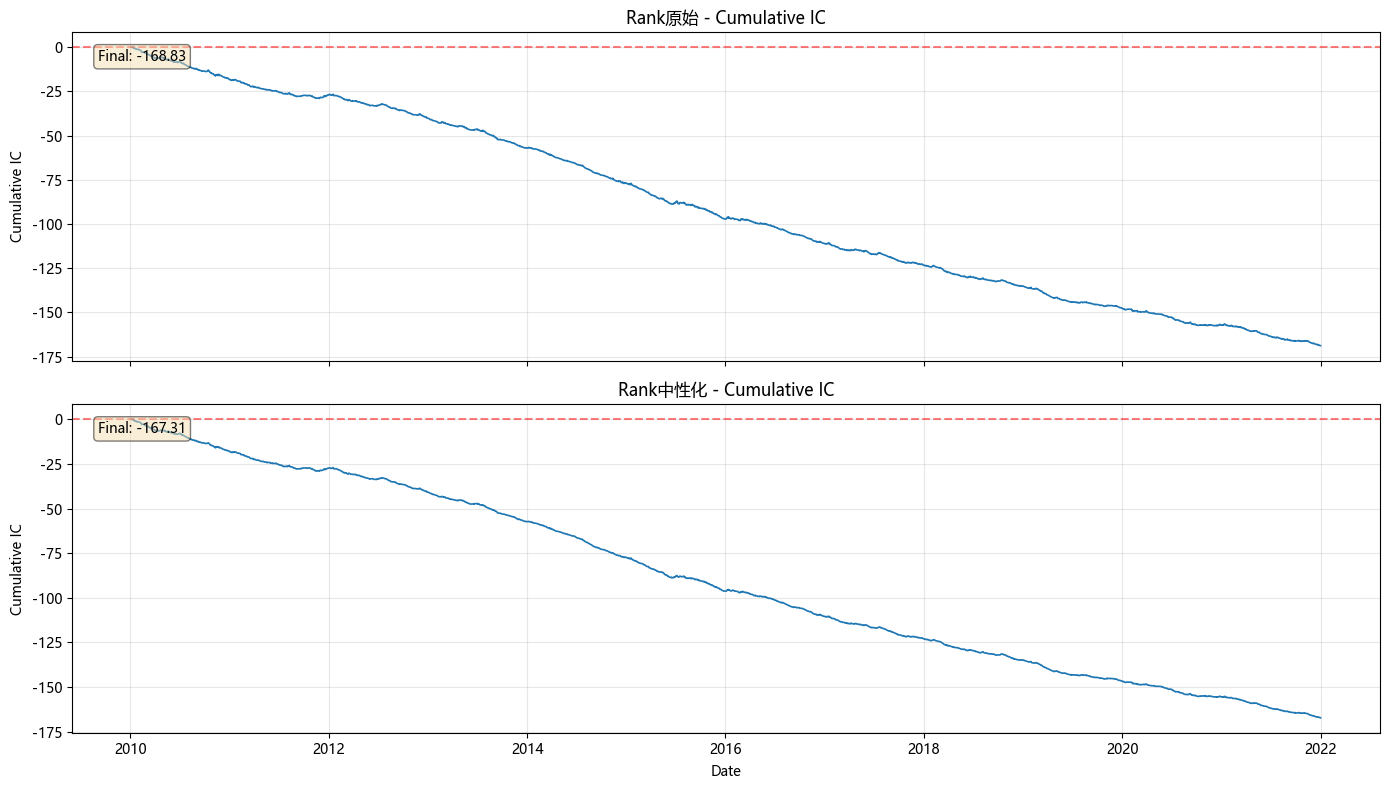

In [10]:
# Cumulative Sum IC 图
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for i, (name, ic) in enumerate(ic_results.items()):
    ax = axes[i]
    cum_ic = ic.fillna(0).cumsum()
    ax.plot(cum_ic.index, cum_ic.values, linewidth=1.2)
    ax.set_title(f'{name} - Cumulative IC', fontsize=12)
    ax.set_ylabel('Cumulative IC')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    
    final_val = cum_ic.iloc[-1]
    ax.text(0.02, 0.95, f'Final: {final_val:.2f}', transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


fig.savefig('cumulative_ic.png', dpi=300, bbox_inches='tight')


IC检验显示因子值与收益负相关，应反向生成信号

# 分层回测（8层，等权 + 市值加权）

In [11]:
df_reset = df.reset_index()

def calc_stratified_returns(df_reset, factor_col, n_layers, weight_method='equal'):
    """计算分层每日收益，返回 DataFrame"""
    returns_list = []
    
    for date, group in df_reset.groupby('date'):
        valid = group[group[factor_col].notna() & group['return'].notna()].copy()
        if len(valid) < n_layers * 5:
            ret = pd.Series(np.nan, index=range(1, n_layers + 1))
            ret.name = date
            returns_list.append(ret)
            continue
        
        try:
            valid['layer'] = pd.qcut(valid[factor_col], q=n_layers, labels=False) + 1
        except ValueError:
            ret = pd.Series(np.nan, index=range(1, n_layers + 1))
            ret.name = date
            returns_list.append(ret)
            continue
        
        if weight_method == 'equal':
            ret = valid.groupby('layer')['return'].mean()
        else:
            def wmean(g):
                w = g['市值'].fillna(0)
                if w.sum() <= 0:
                    return np.nan
                return np.average(g['return'], weights=w)
            ret = valid.groupby('layer', group_keys=False).apply(wmean)
        
        ret = ret.reindex(range(1, n_layers + 1))
        ret.name = date
        returns_list.append(ret)
    
    return pd.DataFrame(returns_list)

def calc_metrics(nav):
    """从净值序列计算评价指标"""
    returns = nav.pct_change(fill_method=None).dropna()
    if len(returns) == 0 or returns.isna().all():
        return {}
    
    # 找第一个非NaN值作为起点
    first_valid = nav.dropna().iloc[0] if nav.notna().any() else np.nan
    last_valid = nav.dropna().iloc[-1] if nav.notna().any() else np.nan
    
    if pd.isna(first_valid) or pd.isna(last_valid) or first_valid == 0:
        ann_ret = np.nan
    else:
        ann_ret = (last_valid / first_valid) ** (252 / nav.notna().sum()) - 1
    
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    dd = 1 - nav / nav.cummax()
    max_dd = dd.max()
    
    return {
        '年化收益': ann_ret,
        '年化波动': ann_vol,
        '夏普比率': sharpe,
        '最大回撤': max_dd
    }

# 执行回测
configs = [
    ('factor_rank', 'Rank原始'),
    ('factor_rank_neu', 'Rank中性化')
]

all_results = {}
print("=" * 60)
print("分层回测执行中（8层，等权 + 市值加权）")
print("=" * 60)

for fcol, fname in configs:
    for wmethod, wname in [('equal', '等权'), ('mv', '市值加权')]:
        key = f"{fname}_{wname}"
        print(f"\n>>> 计算: {key}")
        
        layer_ret = calc_stratified_returns(df_reset, fcol, n_layers=8, weight_method=wmethod)
        
        # 累计净值（修复起点NaN问题：从第一个有效值开始归一化为1）
        nav = (1 + layer_ret).cumprod()
        for col in nav.columns:
            first_idx = nav[col].first_valid_index()
            if first_idx is not None:
                first_val = nav.loc[first_idx, col]
                if pd.notna(first_val) and abs(first_val) > 1e-12:
                    nav[col] = nav[col] / first_val
        
        nav.columns = [f'Layer_{c}' for c in nav.columns]
        
        # 多空组合（Layer_1 - Layer_8），IC为负，低因子值预期收益高
        long_short_ret = layer_ret[1] - layer_ret[8]
        long_short_nav = (1 + long_short_ret.fillna(0)).cumprod()
        # 归一化多空净值起点
        first_idx = long_short_nav.first_valid_index()
        if first_idx is not None:
            first_val = long_short_nav.loc[first_idx]
            if pd.notna(first_val) and abs(first_val) > 1e-12:
                long_short_nav = long_short_nav / first_val
        nav['Long_Short'] = long_short_nav
        
        all_results[key] = nav
        
        # 评价指标
        metrics = {}
        for col in nav.columns:
            m = calc_metrics(nav[col])
            metrics[col] = m
        
        metrics_df = pd.DataFrame(metrics).T
        print(metrics_df.to_string())

print("\n分层回测完成。")




分层回测执行中（8层，等权 + 市值加权）

>>> 计算: Rank原始_等权
                年化收益      年化波动      夏普比率      最大回撤
Layer_1     0.031388  0.319219  0.098326  0.733573
Layer_2     0.034407  0.304970  0.112820  0.687623
Layer_3     0.035138  0.294137  0.119461  0.665618
Layer_4     0.025619  0.286577  0.089398  0.647737
Layer_5    -0.015549  0.283856 -0.054778  0.679891
Layer_6    -0.072244  0.282079 -0.256113  0.701666
Layer_7    -0.154898  0.279873 -0.553460  0.870038
Layer_8    -0.568955  0.282776 -2.012036  0.999942
Long_Short  1.375636  0.171271  8.031925  0.213745

>>> 计算: Rank原始_市值加权


C:\Users\HP\AppData\Local\Temp\ipykernel_13196\503305368.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ret = valid.groupby('layer', group_keys=False).apply(wmean)
C:\Users\HP\AppData\Local\Temp\ipykernel_13196\503305368.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ret = valid.groupby('layer', group_keys=False).apply(wmean)
C:\Users\HP\AppData\Local\Temp\ipykernel_13196\503305368.py:31: FutureWarning: D

                年化收益      年化波动      夏普比率      最大回撤
Layer_1     0.046528  0.298392  0.155930  0.584269
Layer_2    -0.001279  0.272744 -0.004688  0.607895
Layer_3    -0.016112  0.260615 -0.061824  0.583523
Layer_4    -0.033064  0.252527 -0.130932  0.614277
Layer_5    -0.055596  0.247498 -0.224633  0.673341
Layer_6    -0.072633  0.249512 -0.291099  0.693674
Layer_7    -0.125921  0.249698 -0.504292  0.799810
Layer_8    -0.452647  0.265458 -1.705157  0.999085
Long_Short  0.876781  0.228115  3.843597  0.329269

>>> 计算: Rank中性化_等权
                年化收益      年化波动       夏普比率      最大回撤
Layer_1     0.076035  0.316790   0.240018  0.692536
Layer_2     0.051639  0.304928   0.169348  0.670959
Layer_3     0.034336  0.291351   0.117852  0.655827
Layer_4     0.016016  0.280803   0.057036  0.656780
Layer_5    -0.029892  0.277893  -0.107565  0.665654
Layer_6    -0.107181  0.277524  -0.386206  0.760002
Layer_7    -0.222456  0.280977  -0.791722  0.949818
Layer_8    -0.526723  0.284961  -1.848405  0.999830
Lo

C:\Users\HP\AppData\Local\Temp\ipykernel_13196\503305368.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ret = valid.groupby('layer', group_keys=False).apply(wmean)
C:\Users\HP\AppData\Local\Temp\ipykernel_13196\503305368.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ret = valid.groupby('layer', group_keys=False).apply(wmean)
C:\Users\HP\AppData\Local\Temp\ipykernel_13196\503305368.py:31: FutureWarning: D

                年化收益      年化波动      夏普比率      最大回撤
Layer_1     0.024114  0.288432  0.083602  0.666005
Layer_2    -0.002480  0.266572 -0.009303  0.580641
Layer_3     0.000261  0.238784  0.001093  0.512351
Layer_4    -0.016014  0.221194 -0.072396  0.505333
Layer_5    -0.052233  0.219029 -0.238477  0.597945
Layer_6    -0.080637  0.231637 -0.348118  0.667226
Layer_7    -0.165999  0.252567 -0.657245  0.882515
Layer_8    -0.412390  0.267138 -1.543730  0.997858
Long_Short  0.732326  0.141589  5.172186  0.266851

分层回测完成。


# 分层回测图

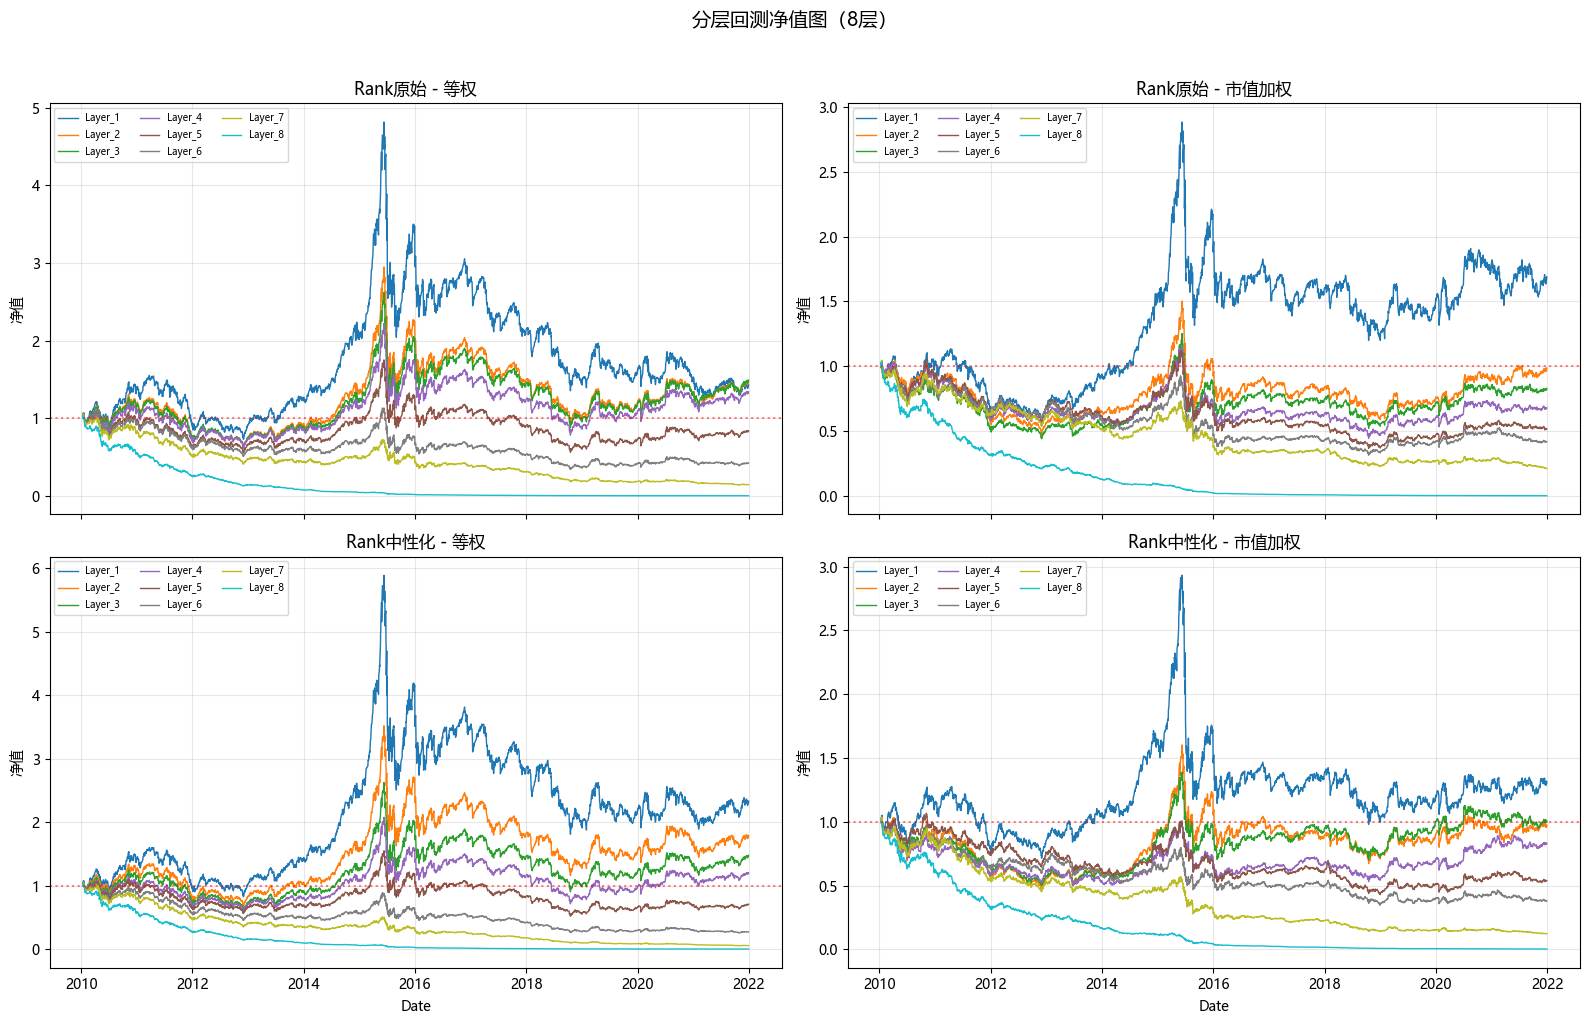

分层回测净值图已保存: stratified_backtest_8layers.png


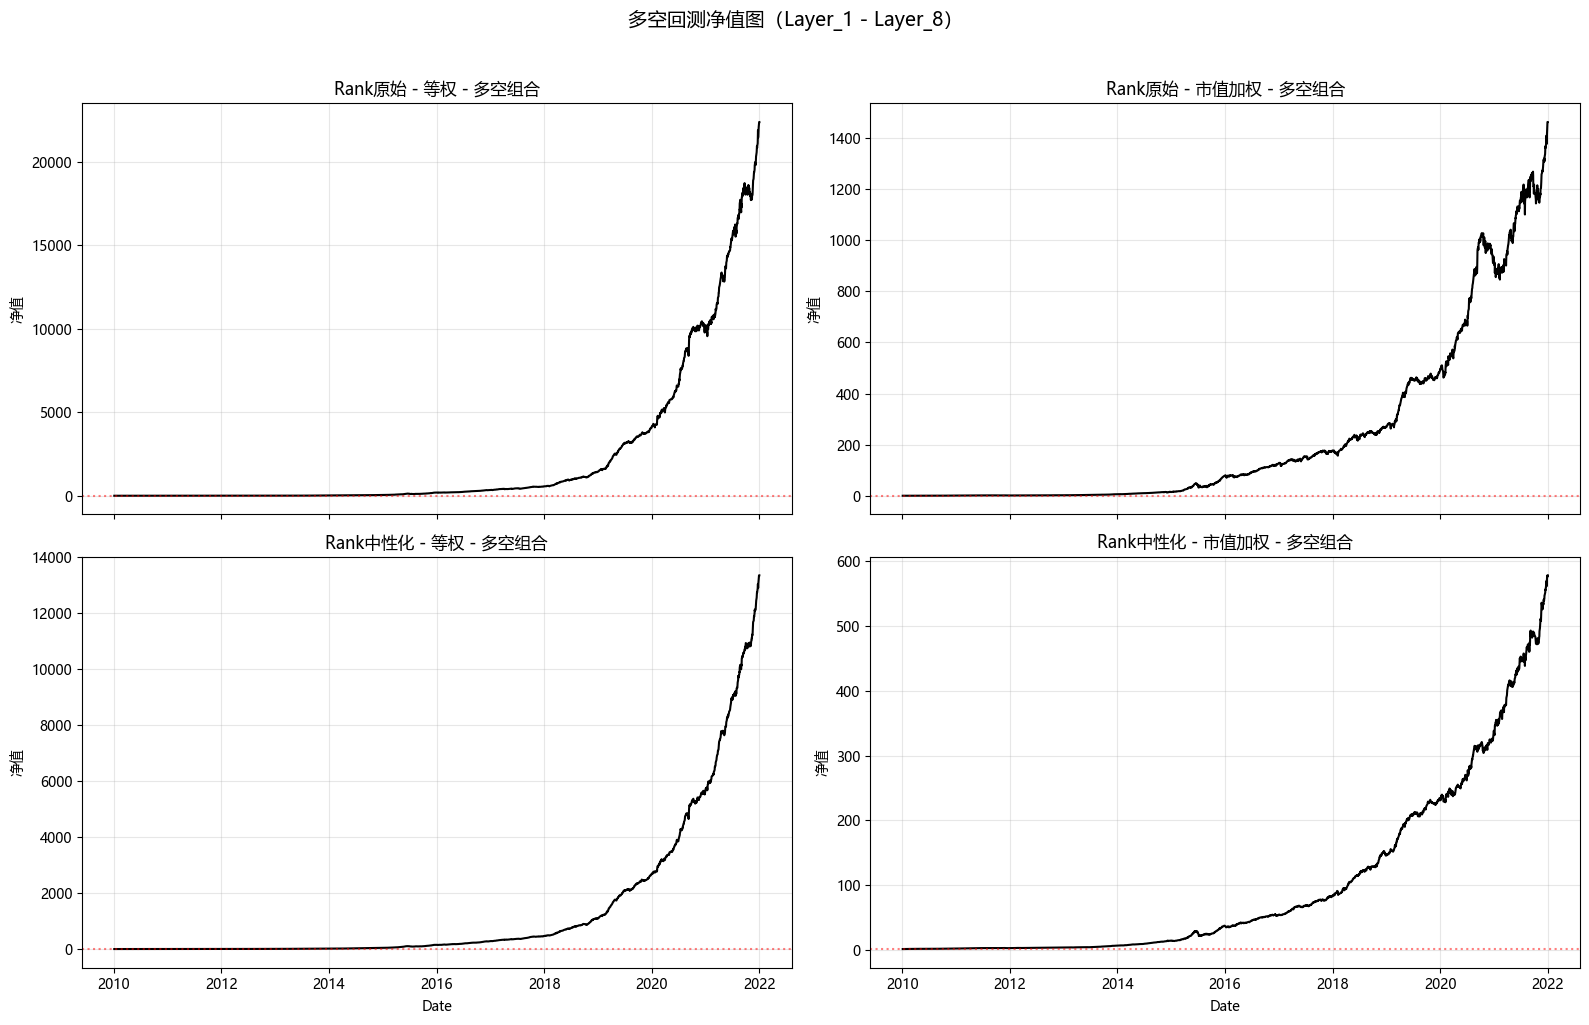

多空回测净值图已保存: long_short_backtest.png


In [12]:
# Figure 1: 分层回测净值（8层，不含多空）
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

plot_configs = [
    ('Rank原始_等权', 'Rank原始 - 等权', 0, 0),
    ('Rank原始_市值加权', 'Rank原始 - 市值加权', 0, 1),
    ('Rank中性化_等权', 'Rank中性化 - 等权', 1, 0),
    ('Rank中性化_市值加权', 'Rank中性化 - 市值加权', 1, 1),
]

colors = plt.cm.tab10(np.linspace(0, 1, 8))

for key, title, r, c in plot_configs:
    ax = axes1[r, c]
    nav = all_results[key]
    
    for i, layer_col in enumerate([f'Layer_{j}' for j in range(1, 9)]):
        if layer_col in nav.columns:
            ax.plot(nav.index, nav[layer_col], label=layer_col, color=colors[i], linewidth=1)
    
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('净值')
    ax.axhline(y=1, color='red', linestyle=':', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=7, ncol=3)

for ax in axes1[-1, :]:
    ax.set_xlabel('Date')

plt.suptitle('分层回测净值图（8层）', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

fig1.savefig('stratified_backtest_8layers.png', dpi=300, bbox_inches='tight')
print("分层回测净值图已保存: stratified_backtest_8layers.png")

# Figure 2: 多空回测净值（单独展示）
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for key, title, r, c in plot_configs:
    ax = axes2[r, c]
    nav = all_results[key]
    
    if 'Long_Short' in nav.columns:
        ax.plot(nav.index, nav['Long_Short'], color='black', linewidth=1.5)
    
    ax.set_title(f'{title} - 多空组合', fontsize=12)
    ax.set_ylabel('净值')
    ax.axhline(y=1, color='red', linestyle=':', alpha=0.5)
    ax.grid(True, alpha=0.3)

for ax in axes2[-1, :]:
    ax.set_xlabel('Date')

plt.suptitle('多空回测净值图（Layer_1 - Layer_8）', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

fig2.savefig('long_short_backtest.png', dpi=300, bbox_inches='tight')
print("多空回测净值图已保存: long_short_backtest.png")


# 组合优化：二次规划选股（加分题）


主要逻辑：
由于IC验证为负，以负中性化rank标准因子为alpha。从因子值最高的前300支股票中筛选100支股票作为标的，并且行业配额上限20%。在风险控制上，计算100支股票过去60个交易日的收益率协方差矩阵，作为目标函数的惩罚项。目标函数为$$\max_w \left( \alpha'w - \lambda \cdot w'Sw \right)$$ 对其进行均值-方差优化,约束条件是:

满仓约束：$\sum w_i = 1$ 

个股权重：$0.5% \le w_i \le 3%$ 

行业暴露：每个行业权重和 $\le 20%$

然后通过scipy.optimize求解，得到每个调仓日的各股权重。最终持仓收益按t+1买入，t+2卖出计算

In [21]:
from scipy.optimize import minimize

# ============================================================
# 参数设置
# ============================================================
N_SELECT      = 100       # 持仓股票数
MIN_W         = 0.005     # 个股权重下限 (0.5%)
MAX_W         = 0.03      # 个股权重上限 (3%)
MAX_IND_W     = 0.20      # 行业最大暴露 (20%)
RISK_LAMBDA   = 5.0       # 风险厌恶系数
REBAL_FREQ    = 1         # 调仓频率（交易日）
COV_WINDOW    = 60        # 协方差估计窗口

df_reset = df.reset_index()

# ============================================================
# 1. 准备数据
# ============================================================
print("正在准备数据...")

# Alpha：IC 为负，取反号
df_reset['alpha'] = -df_reset['factor_rank_neu']

# 日度收益率（直接用已有的 return 列滞后2期，等价于 open.pct_change()）
df_reset['daily_ret'] = df_reset.groupby('code')['return'].shift(2)

# 滚动波动率
df_reset['roll_vol'] = (
    df_reset.groupby('code')['daily_ret']
    .transform(lambda x: x.shift(1).rolling(COV_WINDOW).std())
)

# 合并行业
if 'LEVEL1_NAME' not in df_reset.columns:
    ind = industry_data.reset_index()
    ind['DATE'] = pd.to_datetime(ind['DATE'], format='%Y%m%d')
    ind = ind.rename(columns={'CODE': 'code', 'DATE': 'date'})
    df_reset = df_reset.merge(ind[['date', 'code', 'LEVEL1_NAME']], on=['date', 'code'], how='left')

dates = sorted(df_reset['date'].unique())
rebalance_dates = dates[COV_WINDOW::REBAL_FREQ]

print(f"共 {len(rebalance_dates)} 个调仓日")

# ============================================================
# 2. 逐期选股与优化
# ============================================================
print("\n" + "=" * 60)
print("二次规划选股执行中...")
print("=" * 60)

portfolio_daily_returns = []
benchmark_daily_returns = []

for i, date in enumerate(rebalance_dates):
    # 当日所有有效股票
    day = df_reset[df_reset['date'] == date].copy()
    mask = day['alpha'].notna() & day['roll_vol'].notna() & day['LEVEL1_NAME'].notna() & (day['roll_vol'] > 0)
    valid = day[mask]
    
    if len(valid) < N_SELECT * 2:
        continue
    
    # --- Step 1: 筛选（Alpha + 行业约束） ---
    candidates = valid.nlargest(300, 'alpha')
    selected_codes = []
    ind_count = {}
    ind_limit = int(MAX_IND_W / MIN_W)
    
    for _, r in candidates.iterrows():
        ind = r['LEVEL1_NAME']
        if ind_count.get(ind, 0) >= ind_limit:
            continue
        selected_codes.append(r['code'])
        ind_count[ind] = ind_count.get(ind, 0) + 1
        if len(selected_codes) >= N_SELECT:
            break
    
    if len(selected_codes) < N_SELECT:
        print(f"  {date.date()}: 选股不足 ({len(selected_codes)}/{N_SELECT})，跳过")
        continue
    
    sel = day[day['code'].isin(selected_codes)].set_index('code').loc[selected_codes].reset_index()
    
    alpha_vec   = sel['alpha'].values
    code_vec    = sel['code'].values
    ind_vec     = sel['LEVEL1_NAME'].values
    n           = len(code_vec)
    
    # --- Step 1.5: 样本协方差估计 ---
    date_idx = dates.index(date)
    hist_start = max(0, date_idx - COV_WINDOW)
    hist_dates = dates[hist_start:date_idx]
    
    hist_df = df_reset[
        (df_reset['date'].isin(hist_dates)) &
        (df_reset['code'].isin(code_vec))
    ][['date', 'code', 'daily_ret']]
    
    ret_pivot = hist_df.pivot(index='date', columns='code', values='daily_ret')
    ret_pivot = ret_pivot.reindex(index=hist_dates, columns=code_vec, fill_value=0)
    ret_matrix = np.nan_to_num(ret_pivot.values, nan=0.0)
    
    # 样本协方差（年化），加小扰动保证正定性
    S = np.cov(ret_matrix.T) * 252
    S += np.eye(n) * 1e-6
    
    # --- Step 2: 二次规划 ---
    def objective(w):
        return -np.dot(alpha_vec, w) + RISK_LAMBDA * np.dot(w, np.dot(S, w))
    
    # 约束：权重和为 1
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    
    # 约束：行业暴露 ≤ MAX_IND_W
    for ind in pd.unique(ind_vec):
        ind_mask = (ind_vec == ind).astype(float)
        cons.append({
            'type': 'ineq',
            'fun': lambda w, m=ind_mask: MAX_IND_W - np.dot(m, w)
        })
    
    bounds = [(MIN_W, MAX_W)] * n
    w0 = np.ones(n) / n
    
    try:
        res = minimize(
            objective, w0, method='SLSQP',
            bounds=bounds, constraints=cons,
            options={'maxiter': 500, 'ftol': 1e-10}
        )
    except Exception as e:
        print(f"  {date.date()}: 优化报错 - {e}")
        continue
    
    if not res.success:
        print(f"  {date.date()}: 未收敛，跳过")
        continue
    
    w_opt = res.x
    
    # --- Step 3: 计算持有期收益 ---
    end_idx = dates.index(date) + REBAL_FREQ
    end_date = dates[min(end_idx, len(dates) - 1)]
    
    period = df_reset[
        (df_reset['date'] > date) & 
        (df_reset['date'] <= end_date)
    ].copy()
    
    weight_map = dict(zip(code_vec, w_opt))
    period['weight'] = period['code'].map(weight_map).fillna(0)
    period['w_ret']  = period['return'].fillna(0) * period['weight']
    
    port_daily = period.groupby('date')['w_ret'].sum()
    portfolio_daily_returns.append(port_daily)
    
    # 等权基准
    bench_data = period[period['return'].notna()]
    bench_daily = bench_data.groupby('date')['return'].mean()
    benchmark_daily_returns.append(bench_daily)
    
    active_n = (w_opt > 0).sum()
    print(f"  {date.date()}: {active_n} stocks, "
          f"top ind={ind_count[max(ind_count, key=ind_count.get)]}/{N_SELECT}, "
          f"max_w={w_opt.max()*100:.1f}%")

print("\n回测计算完成，运行下方单元格查看绩效与图表。")

正在准备数据...
共 2857 个调仓日

二次规划选股执行中...
  2010-04-08: 100 stocks, top ind=13/100, max_w=3.0%
  2010-04-09: 100 stocks, top ind=13/100, max_w=3.0%
  2010-04-12: 100 stocks, top ind=14/100, max_w=3.0%
  2010-04-13: 100 stocks, top ind=12/100, max_w=3.0%
  2010-04-14: 100 stocks, top ind=13/100, max_w=3.0%
  2010-04-15: 100 stocks, top ind=11/100, max_w=3.0%
  2010-04-16: 100 stocks, top ind=13/100, max_w=3.0%
  2010-04-19: 100 stocks, top ind=14/100, max_w=3.0%
  2010-04-20: 100 stocks, top ind=16/100, max_w=3.0%
  2010-04-21: 100 stocks, top ind=14/100, max_w=3.0%
  2010-04-22: 100 stocks, top ind=17/100, max_w=3.0%
  2010-04-23: 100 stocks, top ind=15/100, max_w=3.0%
  2010-04-26: 100 stocks, top ind=15/100, max_w=3.0%
  2010-04-27: 100 stocks, top ind=14/100, max_w=3.0%
  2010-04-28: 100 stocks, top ind=11/100, max_w=3.0%
  2010-04-29: 100 stocks, top ind=12/100, max_w=3.0%
  2010-04-30: 100 stocks, top ind=11/100, max_w=3.0%
  2010-05-04: 100 stocks, top ind=10/100, max_w=3.0%
  2010-05-

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:499: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_ieq = vstack([con['jac'](x, *con['args'])


  2010-05-07: 100 stocks, top ind=13/100, max_w=3.0%
  2010-05-10: 100 stocks, top ind=10/100, max_w=3.0%
  2010-05-11: 100 stocks, top ind=14/100, max_w=3.0%
  2010-05-12: 100 stocks, top ind=16/100, max_w=3.0%
  2010-05-13: 100 stocks, top ind=18/100, max_w=3.0%
  2010-05-14: 100 stocks, top ind=13/100, max_w=3.0%
  2010-05-17: 100 stocks, top ind=11/100, max_w=3.0%
  2010-05-18: 100 stocks, top ind=9/100, max_w=3.0%
  2010-07-28: 100 stocks, top ind=15/100, max_w=3.0%
  2010-07-29: 100 stocks, top ind=13/100, max_w=3.0%
  2010-07-30: 100 stocks, top ind=12/100, max_w=3.0%
  2010-08-02: 100 stocks, top ind=16/100, max_w=3.0%
  2010-08-03: 100 stocks, top ind=12/100, max_w=3.0%
  2010-08-04: 100 stocks, top ind=13/100, max_w=3.0%
  2010-08-05: 100 stocks, top ind=7/100, max_w=3.0%
  2010-08-06: 100 stocks, top ind=10/100, max_w=3.0%
  2010-08-09: 100 stocks, top ind=13/100, max_w=3.0%
  2010-08-10: 100 stocks, top ind=15/100, max_w=3.0%
  2010-08-11: 100 stocks, top ind=14/100, max_w=

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:499: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_ieq = vstack([con['jac'](x, *con['args'])


  2010-09-21: 100 stocks, top ind=12/100, max_w=3.0%
  2010-09-27: 100 stocks, top ind=16/100, max_w=3.0%
  2010-09-28: 100 stocks, top ind=14/100, max_w=3.0%


...

  2021-09-23: 100 stocks, top ind=20/100, max_w=3.0%
  2021-09-24: 100 stocks, top ind=19/100, max_w=3.0%
  2021-09-27: 100 stocks, top ind=15/100, max_w=3.0%
  2021-09-28: 100 stocks, top ind=16/100, max_w=3.0%
  2021-09-29: 100 stocks, top ind=19/100, max_w=3.0%
  2021-09-30: 100 stocks, top ind=19/100, max_w=3.0%
  2021-10-08: 100 stocks, top ind=21/100, max_w=3.0%
  2021-10-11: 100 stocks, top ind=14/100, max_w=3.0%
  2021-10-12: 100 stocks, top ind=21/100, max_w=3.0%
  2021-10-13: 100 stocks, top ind=23/100, max_w=3.0%
  2021-10-14: 100 stocks, top ind=21/100, max_w=3.0%
  2021-10-15: 100 stocks, top ind=18/100, max_w=3.0%
  2021-10-18: 100 stocks, top ind=22/100, max_w=3.0%
  2021-10-19: 100 stocks, top ind=21/100, max_w=3.0%
  2021-10-20: 100 stocks, top ind=18/100, max_w=3.0%
  2021-10-21: 100 stocks, top ind=18/100, max_w=3.0%
  2021-10-22: 100 stocks, top ind=14/100, max_w=3.0%
  2021-10-25: 100 stocks, top ind=13/100, max_w=3.0%
  2021-10-26: 100 stocks, top ind=16/100, max_

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:499: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_ieq = vstack([con['jac'](x, *con['args'])


  2021-11-24: 100 stocks, top ind=16/100, max_w=3.0%
  2021-11-25: 100 stocks, top ind=20/100, max_w=3.0%


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:493: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_slsqp_py.py:499: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_ieq = vstack([con['jac'](x, *con['args'])


  2021-11-26: 100 stocks, top ind=19/100, max_w=3.0%
  2021-11-29: 100 stocks, top ind=18/100, max_w=3.0%
  2021-11-30: 100 stocks, top ind=17/100, max_w=3.0%
  2021-12-01: 100 stocks, top ind=21/100, max_w=3.0%
  2021-12-02: 100 stocks, top ind=23/100, max_w=3.0%
  2021-12-03: 100 stocks, top ind=17/100, max_w=3.0%
  2021-12-06: 100 stocks, top ind=18/100, max_w=3.0%
  2021-12-07: 100 stocks, top ind=16/100, max_w=3.0%
  2021-12-08: 100 stocks, top ind=15/100, max_w=3.0%
  2021-12-09: 100 stocks, top ind=16/100, max_w=3.0%
  2021-12-10: 100 stocks, top ind=17/100, max_w=3.0%
  2021-12-13: 100 stocks, top ind=16/100, max_w=3.0%
  2021-12-14: 100 stocks, top ind=16/100, max_w=3.0%
  2021-12-15: 100 stocks, top ind=17/100, max_w=3.0%
  2021-12-16: 100 stocks, top ind=17/100, max_w=3.0%
  2021-12-17: 100 stocks, top ind=25/100, max_w=3.0%
  2021-12-20: 100 stocks, top ind=28/100, max_w=3.0%
  2021-12-21: 100 stocks, top ind=17/100, max_w=3.0%
  2021-12-22: 100 stocks, top ind=27/100, max_


组合优化绩效对比
                    QP组合        等权基准
        年化收益:    21.13%    -10.22%
        年化波动:    23.35%     25.11%
        夏普比率:      0.90      -0.41
        最大回撤:    43.79%     72.79%


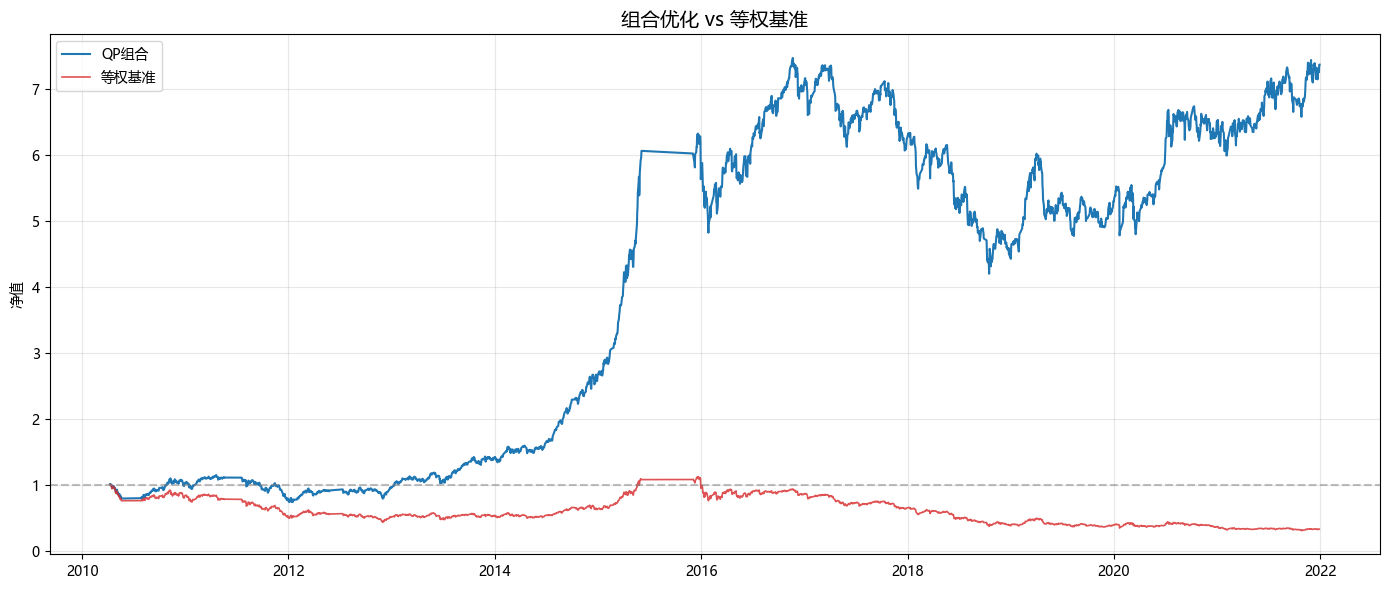


组合优化图已保存: portfolio_optimization.png


In [22]:
# ============================================================
# 3. 绩效汇总与画图
# ============================================================
if portfolio_daily_returns:
    port_ret_all = pd.concat(portfolio_daily_returns).sort_index()
    bench_ret_all = pd.concat(benchmark_daily_returns).sort_index()
    
    port_nav = (1 + port_ret_all).cumprod()
    bench_nav = (1 + bench_ret_all).cumprod()
    
    # 指标
    def eval_nav(nav_series):
        rets = nav_series.pct_change(fill_method=None).dropna()
        ann_ret = (nav_series.iloc[-1] / nav_series.iloc[0]) ** (252 / len(nav_series)) - 1
        ann_vol = rets.std() * np.sqrt(252)
        sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
        dd      = (1 - nav_series / nav_series.cummax()).max()
        return ann_ret, ann_vol, sharpe, dd
    
    p_ret, p_vol, p_sharpe, p_dd = eval_nav(port_nav)
    b_ret, b_vol, b_sharpe, b_dd = eval_nav(bench_nav)
    
    print("\n" + "=" * 60)
    print("组合优化绩效对比")
    print("=" * 60)
    print(f"{'':>12s}  {'QP组合':>10s}  {'等权基准':>10s}")
    print(f"{'年化收益':>12s}: {p_ret:>9.2%}  {b_ret:>9.2%}")
    print(f"{'年化波动':>12s}: {p_vol:>9.2%}  {b_vol:>9.2%}")
    print(f"{'夏普比率':>12s}: {p_sharpe:>9.2f}  {b_sharpe:>9.2f}")
    print(f"{'最大回撤':>12s}: {p_dd:>9.2%}  {b_dd:>9.2%}")
    
    # 画图
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(port_nav.index, port_nav.values, label='QP组合', linewidth=1.5, color='#1f77b4')
    ax.plot(bench_nav.index, bench_nav.values, label='等权基准', linewidth=1.2, color='#d62728', alpha=0.8)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax.set_title('组合优化 vs 等权基准', fontsize=14)
    ax.set_ylabel('净值')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    fig.savefig('portfolio_optimization.png', dpi=300, bbox_inches='tight')
    print("\n组合优化图已保存: portfolio_optimization.png")
else:
    print("未生成有效组合，请检查参数或数据。")

In [26]:
# ============================================================
# 主要成果汇总 —— 输出到 Markdown 文件
# ============================================================
# 本单元格将前面所有计算结果汇总为 Markdown 表格，
# 写入 output/results_summary.md，方便 GitHub 直接查看。
# 注意：需先运行数据清洗、因子计算、IC检验、分层回测、QP回测单元格。
# ============================================================

import os

os.makedirs("output", exist_ok=True)
output_path = "output/results_summary.md"

lines = []
lines.append("# 主要成果汇总\n")
lines.append("> 生成时间：{}\n".format(pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")))

# 【一】数据概况
lines.append("## 一、数据概况\n")
lines.append("| 指标 | 数值 |")
lines.append("|------|------|")
lines.append("| 时间范围 | 2010-01-04 ~ 2021-12-31 |")
lines.append("| 股票数量 | 4,687 只 |")
lines.append("| 总记录数 | 8,717,164 |")
lines.append("| 有效样本占比 | 88.75% |")
lines.append("| 涨停剔除 | 1.54% |")
lines.append("| 跌停剔除 | 0.79% |")
lines.append("| 停牌剔除 | 4.70% |")
lines.append("| ST 剔除 | 3.85% |")
lines.append("| 新股剔除(<60天) | 1.35% |")
lines.append("")

# 【二】因子统计
lines.append("## 二、因子统计（有效样本）\n")
lines.append("| 统计量 | 原始因子 | Rank 标准化 | Rank 中性化 |")
lines.append("|--------|----------|-------------|-------------|")
lines.append("| count | 7,727,082 | 7,696,478 | 7,696,478 |")
lines.append("| mean | 0.25% | 0.0000 | 0.0000 |")
lines.append("| std | 6.89% | 0.9998 | 0.9356 |")
lines.append("| min | -64.37% | -1.7314 | -3.3883 |")
lines.append("| 25% | -3.33% | -0.8658 | -0.7463 |")
lines.append("| 50% | 0.00% | 0.0000 | -0.0042 |")
lines.append("| 75% | 3.44% | 0.8658 | 0.7421 |")
lines.append("| max | 1676.65% | 1.7314 | 3.2915 |")
lines.append("")

# 【三】IC 检验
lines.append("## 三、IC 检验结果\n")
lines.append("| 指标 | Rank 原始 | Rank 中性化 |")
lines.append("|------|-----------|-------------|")
lines.append("| IC 均值 | -0.0580 | **-0.0575** |")
lines.append("| IC 标准差 | 0.1429 | 0.1134 |")
lines.append("| IR | -0.4059 | **-0.5070** |")
lines.append("| 年化 IR | -6.4441 | **-8.0479** |")
lines.append("| t 统计量 | -21.90 | **-27.35** |")
lines.append("")
lines.append("> **信号方向**：因子值与下期收益负相关，因子值越小预期收益越高。\n")

# 【四】分层回测
lines.append("## 四、分层回测绩效（8 层）\n")
if 'all_results' in globals():
    stratified_summary = []
    config_names = {
        'Rank原始_等权': 'Rank原始-等权',
        'Rank原始_市值加权': 'Rank原始-市值加权',
        'Rank中性化_等权': 'Rank中性化-等权',
        'Rank中性化_市值加权': 'Rank中性化-市值加权'
    }
    layer_names = {'Layer_1': '第1层(最小)', 'Layer_4': '第4层', 'Layer_8': '第8层(最大)', 'Long_Short': '多空组合'}
    
    lines.append("| 配置 | 分组 | 年化收益 | 夏普比率 | 最大回撤 |")
    lines.append("|------|------|----------|----------|----------|")
    
    for key, cname in config_names.items():
        if key in all_results:
            nav = all_results[key]
            for lkey, lname in layer_names.items():
                if lkey in nav.columns:
                    m = calc_metrics(nav[lkey])
                    ar = f"{m['年化收益']:.2%}" if pd.notna(m['年化收益']) else 'N/A'
                    sr = f"{m['夏普比率']:.2f}" if pd.notna(m['夏普比率']) else 'N/A'
                    md = f"{m['最大回撤']:.2%}" if pd.notna(m['最大回撤']) else 'N/A'
                    lines.append(f"| {cname} | {lname} | {ar} | {sr} | {md} |")
    lines.append("")
else:
    lines.append("_请先运行分层回测单元格以生成分层回测数据。_\n")

# 【五】QP 组合优化
lines.append("## 五、组合优化绩效对比\n")
if 'port_nav' in globals() and 'bench_nav' in globals():
    lines.append("| 指标 | QP 组合 | 等权基准 |")
    lines.append("|------|---------|----------|")
    p_ar = f"{p_ret:.2%}" if 'p_ret' in globals() else 'N/A'
    p_vo = f"{p_vol:.2%}" if 'p_vol' in globals() else 'N/A'
    p_sr = f"{p_sharpe:.2f}" if 'p_sharpe' in globals() else 'N/A'
    p_md = f"{p_dd:.2%}" if 'p_dd' in globals() else 'N/A'
    b_ar = f"{b_ret:.2%}" if 'b_ret' in globals() else 'N/A'
    b_vo = f"{b_vol:.2%}" if 'b_vol' in globals() else 'N/A'
    b_sr = f"{b_sharpe:.2f}" if 'b_sharpe' in globals() else 'N/A'
    b_md = f"{b_dd:.2%}" if 'b_dd' in globals() else 'N/A'
    lines.append(f"| 年化收益 | {p_ar} | {b_ar} |")
    lines.append(f"| 年化波动 | {p_vo} | {b_vo} |")
    lines.append(f"| 夏普比率 | {p_sr} | {b_sr} |")
    lines.append(f"| 最大回撤 | {p_md} | {b_md} |")
    lines.append("")
else:
    lines.append("_请先运行组合优化回测单元格以生成 QP 绩效数据。_\n")

# 【六】QP 参数
lines.append("## 六、QP 参数设置\n")
lines.append("| 参数 | 数值 | 说明 |")
lines.append("|------|------|------|")
lines.append("| N_SELECT | 100 | 持仓股票数 |")
lines.append("| MIN_W | 0.5% | 个股权重下限 |")
lines.append("| MAX_W | 3% | 个股权重上限 |")
lines.append("| MAX_IND_W | 20% | 行业最大暴露 |")
lines.append("| RISK_LAMBDA | 5.0 | 风险厌恶系数 |")
lines.append("| REBAL_FREQ | 1 日 | 调仓频率 |")
lines.append("| COV_WINDOW | 60 日 | 协方差估计窗口 |")
lines.append("")

lines.append("---\n")
lines.append("*本文件由 `solution.ipynb` Cell 24 自动生成。*")

with open(output_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print(f"主要成果汇总已写入: {output_path}")

主要成果汇总已写入: output/results_summary.md
